 Import Libraries


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Data Loading


In [11]:
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset (1).csv')

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


Data Exploration


In [12]:
df.shape

(4000, 28)

In [13]:
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [15]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [16]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df['Season'].unique()

array(['Kharif', 'Rabi', 'Zaid'], dtype=object)

Data Cleaning


In [19]:
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())

In [20]:
df['Season'] = df['Season'].fillna(df['Season'].mode()[0])

In [21]:
df = df.drop_duplicates()

In [22]:
print("Final dataset shape:", df.shape)
print("Missing values:")
print(df.isnull().sum())

Final dataset shape: (4000, 28)
Missing values:
Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                       0
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency

Seasonal distribution

In [23]:
df['Season'].value_counts()

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


In [24]:
season_summary = df.groupby('Season')[['Rainfall_mm', 'Avg_Temperature_C',
                                         'Yield_Tonnes_Ha', 'Profit_INR',
                                         'Water_Efficiency_t_per_1000m3',
                                         'Disease_Pest_Risk_pct']].mean().round(2)
season_summary

,Rainfall_mm,Avg_Temperature_C,Yield_Tonnes_Ha,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,
Kharif,849.20,28.45,5.64,178914.65,5.89,54.47
Rabi,437.62,23.49,5.08,87689.47,5.19,40.48
Zaid,304.65,31.04,4.67,-24804.82,4.41,38.22


Yield distribution by season

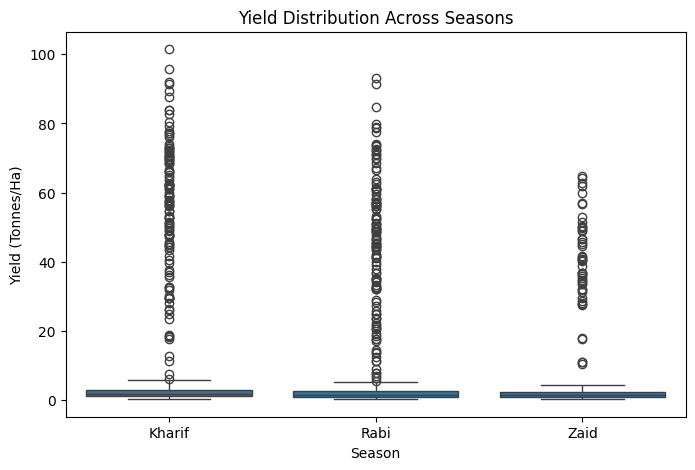

In [34]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha')
plt.title('Yield Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

Average profit by season

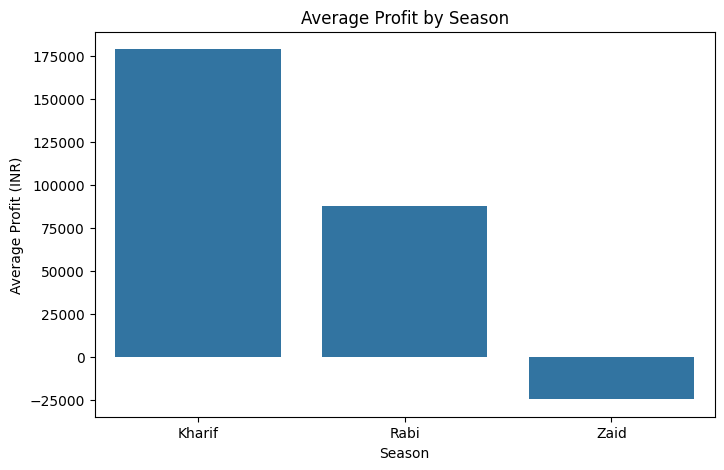

In [33]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Season', y='Profit_INR', estimator=np.mean, errorbar=None)
plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.show()

Rainfall vs Yield, colored by season

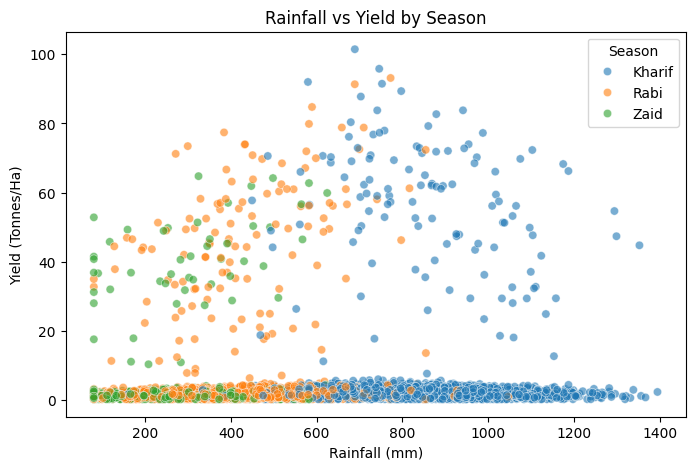

In [35]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', alpha=0.6)
plt.title('Rainfall vs Yield by Season')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

Water efficiency by irrigation method

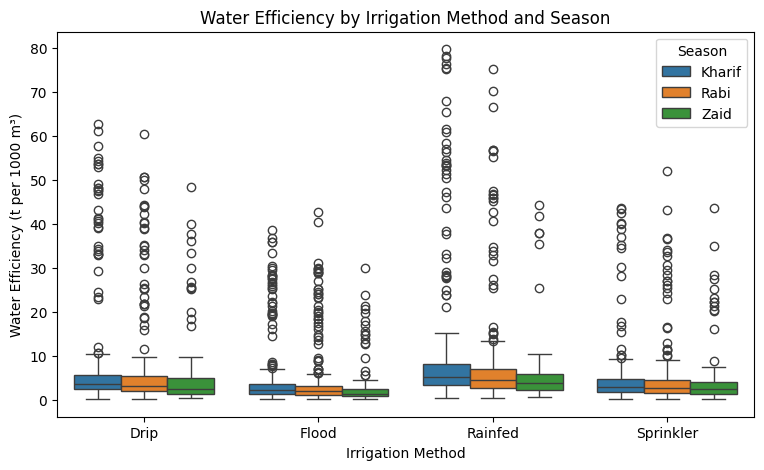

In [36]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', hue='Season')
plt.title('Water Efficiency by Irrigation Method and Season')
plt.xlabel('Irrigation Method')
plt.ylabel('Water Efficiency (t per 1000 m³)')
plt.legend(title='Season')
plt.show()

Disease/pest risk by season

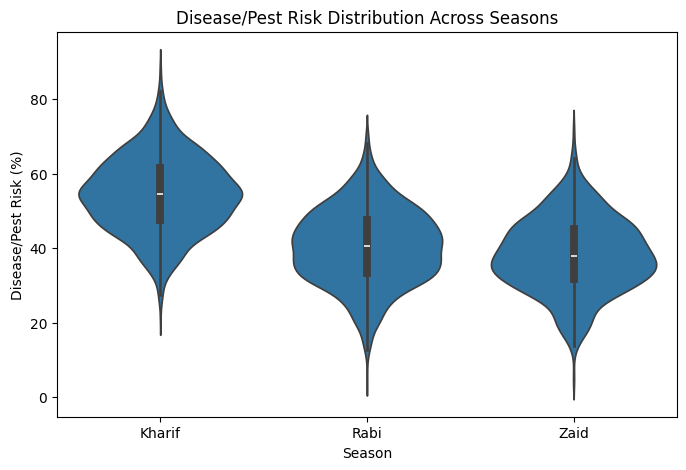

In [38]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x='Season', y='Disease_Pest_Risk_pct')
plt.title('Disease/Pest Risk Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Disease/Pest Risk (%)')
plt.show()

Correlation heatmap

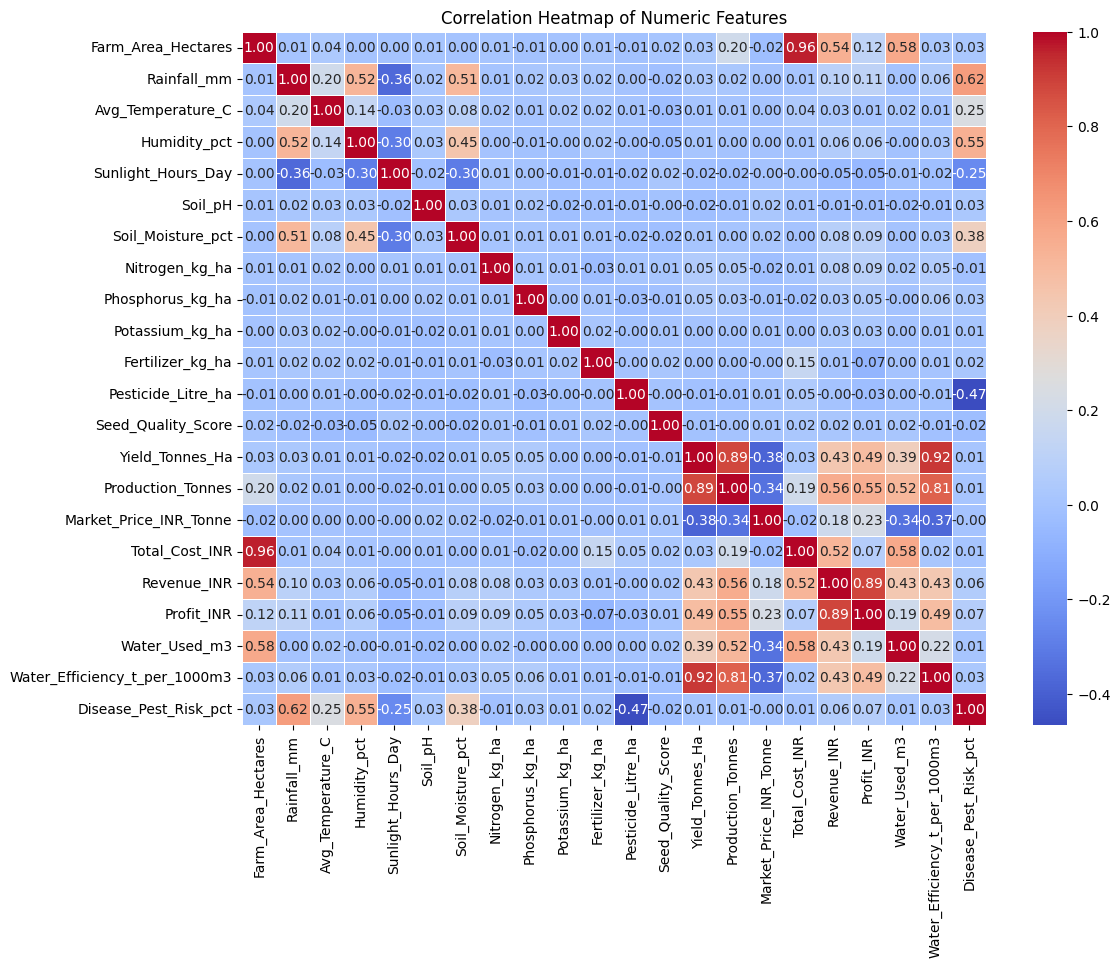

In [39]:
plt.figure(figsize=(12,9))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [40]:
fertilizer_profit = df.groupby('Season')[['Fertilizer_kg_ha', 'Profit_INR']].corr().iloc[0::2, -1]
fertilizer_profit

,,Profit_INR
Season,,
Kharif,Fertilizer_kg_ha,-0.070918
Rabi,Fertilizer_kg_ha,-0.079050
Zaid,Fertilizer_kg_ha,-0.094729


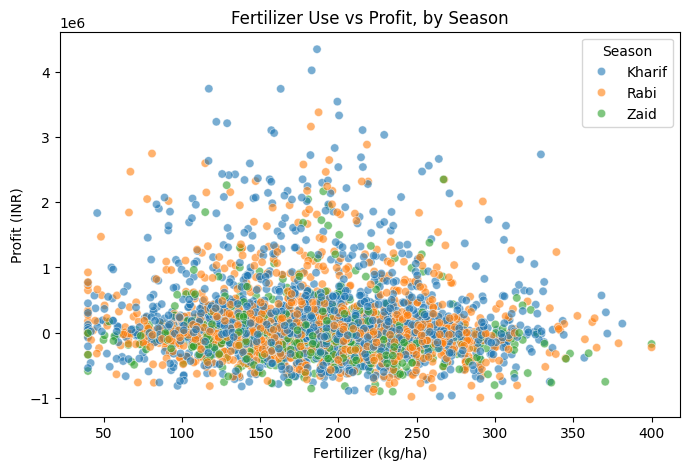

In [41]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Fertilizer_kg_ha', y='Profit_INR', hue='Season', alpha=0.6)
plt.title('Fertilizer Use vs Profit, by Season')
plt.xlabel('Fertilizer (kg/ha)')
plt.ylabel('Profit (INR)')
plt.show()